## Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
path_to_module = '/content/drive/MyDrive/DSML/Custom_Functions'
sys.path.append(path_to_module)

In [ ]:
from Data_Analysis_Visualization import custom_get_df_summary, custom_plot_hist, custom_plot_box, custom_plot_numeric_distribution, custom_plt_dist_plot, custom_plt_most_least10_count_plot, custom_plot_kde_distribution

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import seaborn as sns
# import textwrap
import math
import re
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import RegressionModel

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

In [ ]:
!pip install category_encoders

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 2.0 MB/s eta 0:00:00


In [ ]:
from category_encoders import TargetEncoder

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier

---

#Define Problem Statement and perform Exploratory Data Analysis

**About the Business:**

&emsp;&emsp;Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola. Churn among drivers is high and it’s very easy for drivers to stop working for the service on the fly or jump to Uber depending on the rates.

&emsp;&emsp;As the companies get bigger, the high churn could become a bigger problem. To find new drivers, Ola is casting a wide net, including people who don’t have cars for jobs. But this acquisition is really costly. Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.

**Business Problem**

&emsp;&emsp;Being a data scientist at Analytics Department of Ola, you task is to focus on driver team attrition. You are provided with the monthly information for a segment of drivers for 2019 and 2020 and tasked to predict whether a driver will be leaving the company or not based on their attributes like

- Demographics (city, age, gender etc.)
- Tenure information (joining date, Last Date)
- Historical data regarding the performance of the driver (Quarterly rating, Monthly business acquired, grade, Income)

**Concept Used:**
- Ensemble Learning- Bagging
- Ensemble Learning- Boosting
- KNN Imputation of Missing Values
- Working with an imbalanced dataset


**Download the dataset**

In [ ]:
df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv')
df.head(4)

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


**Columns Profiling:**

- MMMM-YY : Reporting Date (Monthly)
- Driver_ID : Unique id for drivers
- Age : Age of the driver
- Gender : Gender of the driver – Male : 0, Female: 1
- City : City Code of the driver
- Education_Level : Education level – 0 for 10+ ,1 for 12+ ,2 for graduate
- Income : Monthly average Income of the driver
- Date Of Joining : Joining date for the driver
- LastWorkingDate : Last date of working for the driver
- Joining Designation : Designation of the driver at the time of joining
- Grade : Grade of the driver at the time of reporting
- Total Business Value : The total business value acquired by the driver in a month (negative business indicates cancellation/refund or car EMI adjustments)
- Quarterly Rating : Quarterly rating of the driver: 1,2,3,4,5 (higher is better)

**Non-Graphical Univariate Analysis Summary**

- Observe shape of the data, the data types of all attributes
- Missing value detection, outlier checking, statistical summarization

In [ ]:
df_summary = custom_get_df_summary(df, print_summary=False, properties_as_columns=False)

RangeIndex: 19104 entries; Data columns (total 14 columns)
memory usage: 2.0+ MB



In [ ]:
df_summary

,MMM-YY,City,Dateofjoining,LastWorkingDate,Unnamed: 0,Driver_ID,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Age,Gender
dtype,object,object,object,object,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64
Missing Counts,0,0,0,17488,0,0,0,0,0,0,0,0,61,52
nUniques,24,29,869,493,19104,2381,3,2383,5,5,10181,4,36,2
Top 10 Unique Values,"01/01/19 (5%), 02/01/19 (4%), 03/01/19 (4%), 1...","C20 (5%), C29 (4%), C26 (4%), C22 (4%), C27 (4...","23/07/15 (1%), 31/07/20 (0%), 07/04/19 (0%), 2...","29/07/20 (4%), 22/09/19 (1%), 17/03/19 (0%), 2...","0.0 (0%), 12741.0 (0%), 12739.0 (0%), 12738.0 ...","2110.0 (0%), 2617.0 (0%), 1623.0 (0%), 1642.0 ...","1.0 (35%), 2.0 (33%), 0.0 (30%)","48747.0 (0%), 109652.0 (0%), 68356.0 (0%), 422...","1.0 (51%), 2.0 (31%), 3.0 (14%), 4.0 (1%), 5.0...","2.0 (34%), 1.0 (27%), 3.0 (25%), 4.0 (11%), 5....","0.0 (34%), 200000.0 (1%), 250000.0 (0%), 50000...","1.0 (40%), 2.0 (29%), 3.0 (20%), 4.0 (10%)","36.0 (6%), 33.0 (6%), 34.0 (6%), 30.0 (6%), 32...","0.0 (58%), 1.0 (41%)"
Bottom 10 Unique Values,"03/01/20 (3%), 06/01/19 (3%), 04/01/20 (3%), 1...","C17 (2%), C11 (2%), C2 (2%), C9 (2%), C23 (2%)...","20/06/16 (0%), 27/12/20 (0%), 26/09/18 (0%), 1...","28/10/20 (0%), 11/07/19 (0%), 11/02/20 (0%), 2...","0.0 (0%), 12738.0 (0%), 12737.0 (0%), 12736.0 ...","1978.0 (0%), 148.0 (0%), 540.0 (0%), 2281.0 (0...","0.0 (30%), 2.0 (33%), 1.0 (35%)","51579.0 (0%), 50778.0 (0%), 43989.0 (0%), 7218...","5.0 (0%), 4.0 (1%), 3.0 (14%), 2.0 (31%), 1.0 ...","5.0 (1%), 4.0 (11%), 3.0 (25%), 1.0 (27%), 2.0...","2381060.0 (0%), 1442530.0 (0%), 3076690.0 (0%)...","4.0 (10%), 3.0 (20%), 2.0 (29%), 1.0 (40%)","58.0 (0%), 55.0 (0%), 54.0 (0%), 53.0 (0%), 21...","1.0 (41%), 0.0 (58%)"
min,nan,nan,nan,nan,0.0,1.0,0.0,10747.0,1.0,1.0,-6000000.0,1.0,21.0,0.0
max,nan,nan,nan,nan,19103.0,2788.0,2.0,188418.0,5.0,5.0,33747720.0,4.0,58.0,1.0
LW (1.5),nan,nan,nan,nan,0.0,1.0,0.0,10747.0,1.0,1.0,-1049550.0,1.0,21.0,0.0
Q1,nan,nan,nan,nan,4775.8,710.0,0.0,42383.0,1.0,1.0,0.0,1.0,30.0,0.0
Median,nan,nan,nan,nan,9551.5,1417.0,1.0,60087.0,1.0,2.0,250000.0,2.0,34.0,0.0


# Drop the unwanted column

In [ ]:
df = df.drop('Unnamed: 0', axis=1)
df = df.drop('MMM-YY', axis=1)

# Check for duplicate records

In [ ]:
df.duplicated().value_counts()

False    16724
True      2380
dtype: int64

In [ ]:
df = df.drop_duplicates(ignore_index=True)

# Missing Value Treatment using KNN imputation

In [ ]:
X = df.select_dtypes(np.number)
imputer = KNNImputer(n_neighbors=3)
X_imputed = imputer.fit_transform(X)
df[df.select_dtypes(np.number).columns] = X_imputed

In [ ]:
df['Age'] = df['Age'].round()
df['Gender'] = df['Gender'].round()

In [ ]:
df_summary = custom_get_df_summary(df, print_summary=False, properties_as_columns=False)

RangeIndex: 16724 entries; Data columns (total 12 columns)
memory usage: 1.5+ MB



In [ ]:
df_summary

,City,Dateofjoining,LastWorkingDate,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
dtype,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64
Missing Counts,0,0,15108,0,0,0,0,0,0,0,0,0
nUniques,29,869,493,2381,36,2,3,2383,5,5,10181,4
Top 10 Unique Values,"C20 (5%), C29 (4%), C26 (4%), C22 (4%), C27 (4...","23/07/15 (1%), 25/04/16 (0%), 30/07/15 (0%), 0...","29/07/20 (4%), 22/09/19 (1%), 17/03/19 (0%), 2...","1371.0 (0%), 2660.0 (0%), 2541.0 (0%), 2543.0 ...","36.0 (6%), 33.0 (6%), 34.0 (6%), 30.0 (6%), 35...","0.0 (57%), 1.0 (42%)","1.0 (35%), 2.0 (33%), 0.0 (30%)","48747.0 (0%), 109652.0 (0%), 68356.0 (0%), 674...","1.0 (54%), 2.0 (30%), 3.0 (13%), 4.0 (1%), 5.0...","2.0 (34%), 1.0 (27%), 3.0 (24%), 4.0 (12%), 5....","0.0 (25%), 200000.0 (1%), 250000.0 (0%), 50000...","1.0 (33%), 2.0 (32%), 3.0 (23%), 4.0 (11%)"
Bottom 10 Unique Values,"C17 (2%), C2 (2%), C11 (2%), C23 (2%), C9 (2%)...","14/11/20 (0%), 27/12/20 (0%), 26/09/18 (0%), 1...","28/10/20 (0%), 11/07/19 (0%), 11/02/20 (0%), 2...","1971.0 (0%), 1581.0 (0%), 2290.0 (0%), 335.0 (...","58.0 (0%), 55.0 (0%), 54.0 (0%), 53.0 (0%), 21...","1.0 (42%), 0.0 (57%)","0.0 (30%), 2.0 (33%), 1.0 (35%)","68975.0 (0%), 50210.0 (0%), 105510.0 (0%), 704...","5.0 (0%), 4.0 (1%), 3.0 (13%), 2.0 (30%), 1.0 ...","5.0 (1%), 4.0 (12%), 3.0 (24%), 1.0 (27%), 2.0...","2381060.0 (0%), 1442530.0 (0%), 3076690.0 (0%)...","4.0 (11%), 3.0 (23%), 2.0 (32%), 1.0 (33%)"
min,nan,nan,nan,1.0,21.0,0.0,0.0,10747.0,1.0,1.0,-6000000.0,1.0
max,nan,nan,nan,2788.0,58.0,1.0,2.0,188418.0,5.0,5.0,33747720.0,4.0
LW (1.5),nan,nan,nan,1.0,21.0,0.0,0.0,10747.0,1.0,1.0,-1183545.0,1.0
Q1,nan,nan,nan,713.0,30.0,0.0,0.0,42768.0,1.0,1.0,0.0,1.0
Median,nan,nan,nan,1421.5,34.0,0.0,1.0,60655.0,1.0,2.0,331495.0,2.0


# Data type conversion

In [ ]:
for clm in ['Dateofjoining', 'LastWorkingDate']:
  df[clm] = pd.to_datetime(df[clm])

# Outlier Treatment using Z-Score

In [ ]:
df = df.drop(df.loc[((df['Total Business Value'] > float(df_summary.loc['mean+3*std', 'Total Business Value'])) | (df['Total Business Value'] < float(df_summary.loc['mean-3*std', 'Total Business Value'])))].index)

# Data Aggregation

In [ ]:
def modified_mode(ser):
  m = pd.Series.mode(ser)
  if len(m) > 1:
    m = m[0]

  return m

In [ ]:
agg_criteria = {
    'Age': modified_mode,
    'Gender': modified_mode,
    'City': modified_mode,
    'Education_Level': modified_mode,
    'Income': ['min', 'max'],
    'Dateofjoining': 'min',
    'LastWorkingDate': 'max',
    'Joining Designation': modified_mode,
    'Grade': modified_mode,
    'Total Business Value': 'sum',
    'Quarterly Rating': ['min', 'max']
                }

In [ ]:
df_agg = df.groupby('Driver_ID').agg(agg_criteria)
df_agg.head(4)

Age        Gender          City Education_Level   Income  \
          modified_mode modified_mode modified_mode   modified_mode      min   
Driver_ID                                                                      
1.0                28.0           0.0           C23             2.0  57387.0   
2.0                31.0           0.0            C7             2.0  67016.0   
4.0                43.0           0.0           C13             2.0  65603.0   
5.0                29.0           0.0            C9             0.0  46368.0   

                   Dateofjoining LastWorkingDate Joining Designation  \
               max           min             max       modified_mode   
Driver_ID                                                              
1.0        57387.0    2018-12-24      2019-03-11                 1.0   
2.0        67016.0    2020-11-06             NaT                 2.0   
4.0        65603.0    2019-12-07      2020-04-27                 2.0   
5.0        46368.0    2019-01-09      2019-03-07                 1.0   

                  Grade Total Business Value Quarterly Rating       
          modified_mode                  sum              min  max  
Driver_ID                                                           
1.0                 1.0            1715580.0              2.0  2.0  
2.0                 2.0                  0.0              1.0  1.0  
4.0                 2.0             350000.0              1.0  1.0  
5.0                 1.0             120360.0              1.0  1.0

# Feature Engineering, Encoding, Class Imbalance treatment

In [ ]:
df_agg['City'] = df_agg[('City', 'modified_mode')].str[1:]

In [ ]:
df_agg['is_income_increased'] = df_agg['Income']['min'] < df_agg['Income']['max']
df_agg['is_income_increased'] = df_agg['is_income_increased'].map({True: 1, False: 0})
df_agg = df_agg.drop([('Income','min')], axis=1)

In [ ]:
df_agg['is_rating_increased'] = df_agg['Quarterly Rating']['min'] < df_agg['Quarterly Rating']['max']
df_agg['is_rating_increased'] = df_agg['is_rating_increased'].map({True: 1, False: 0})
df_agg = df_agg.drop([('Quarterly Rating','min')], axis=1)

In [ ]:
df_agg.columns = [i[0] for i in df_agg.columns]

In [ ]:
df_agg['is_churned'] = ~df_agg['LastWorkingDate'].isna()
df_agg['is_churned'] = df_agg['is_churned'].map({True: 1, False: 0})

In [ ]:
df_agg['LastWorkingDate'] = df_agg['LastWorkingDate'].fillna(df_agg['LastWorkingDate'].max())
df_agg['tenure_months'] = 12 * (df_agg['LastWorkingDate'].dt.year - df_agg['Dateofjoining'].dt.year) + (df_agg['LastWorkingDate'].dt.month - df_agg['Dateofjoining'].dt.month)
df_agg = df_agg.drop(['LastWorkingDate', 'Dateofjoining'], axis=1)

---

# Univariate and Bivariate Analysis

**Custom Function to get details analysis of a Categorical Variable**

In [ ]:
def analyse_categorical_variable(data=df, var='purpose', target_var='loan_status'):
  if data[var].nunique() <=15:
    fig = plt.figure()
    ax1 = plt.subplot(1, 3, 1)
    ax2 = plt.subplot(1, 3, 2)
    ax3 = plt.subplot(1, 3, 3)

    sns.countplot(ax=ax1, data=data, y=var, order=data[var].value_counts().index, color=sns.color_palette()[0])
    ax1.invert_xaxis()
    # ax1.set_yticks([])
    # ax1.set_yticklabels('')
    ax1.legend('', frameon=False)

    # sns.countplot(ax=ax3, data=data, y=var, order=data[var].value_counts().index, hue=target_var)
    sns.countplot(ax=ax2, data=data, y=var, order=data[var].value_counts().index, hue=target_var)
    ax2.set_ylabel('')

    df2 = data.groupby(var)[target_var].value_counts(normalize=True).mul(100).rename('pct').reset_index()
    df2[var] = df2[var].astype('category')
    sns.barplot(ax=ax3, data=df2, hue=target_var, x='pct', y=var,order=data[var].value_counts().index)
    ax2.set_yticks([])
    ax3.set_yticklabels('')
    ax2.legend('', frameon=False)

    # sns.countplot(ax=ax3, data=data, y=var, order=data[var].value_counts().index, palette = ['darkturquoise']*4 + ['gray']*20)
    ax3.set_ylabel('')
    ax3.set_yticks([])
    ax3.set_yticklabels('')
    ax3.legend(loc='upper left', borderaxespad=0, bbox_to_anchor=(1.01, 1))

    fig.set_size_inches((14, 1+data[var].nunique()/4))
    # fig.subplots_adjust(hspace=0.6, wspace=0.6)
    # fig.tight_layout()

  # Test for Dependance
  pval = stats.chi2_contingency(pd.crosstab(index=data[target_var], columns=data[var]))[1]

  print('Testing for Dependance (Chi2 Test)')
  if pval <= 0.05:
    print(f"Since pval ({pval:.03f}) <= significance level (0.05), Dependant variable ({target_var}) and Predictor variable ({var}): Significnatly Dependant")
  else:
    print(f"Since pval ({pval:.03f}) > significance level (0.05), Dependant variable ({target_var}) and Predictor variable ({var}): Not Dependant")


**Custom Function to get details analysis of a Categorical Variable**

In [ ]:
def analyse_numeric_variable(data=df, var='loan_amnt', target_var='loan_status'):
  fig = plt.figure()
  ax1 = plt.subplot(2, 1, 1)
  ax2 = plt.subplot(2, 1, 2, sharex=ax1)

  sns.histplot(ax=ax1, data=data, x=var, kde=True, bins=30)
  low = max(data[var].mean() - 3*data[var].std(), data[var].min())
  high = min(data[var].mean() + 3*data[var].std(), data[var].max())

  df_low = pd.DataFrame({'x': [low, low], 'y': ax1.get_ybound()})
  df_high = pd.DataFrame({'x': [high, high], 'y': ax1.get_ybound()})
  sns.lineplot(ax=ax1, data=df_low, x='x', y='y', color='red', linestyle='--', estimator=None, linewidth = 1)
  text = 'mean-3*std'
  ax1.annotate(text, xy=(low, 0.7), xycoords=('data', 'figure fraction'), rotation=90)
  sns.lineplot(ax=ax1, data=df_high, x='x', y='y', color='red', linestyle='--', estimator=None, linewidth = 1)
  text = 'mean+3*std'
  ax1.annotate(text, xy=(high, 0.7), xycoords=('data', 'figure fraction'), rotation=90)
  ax1.set_xlabel('')

  sns.histplot(ax=ax2, data=data, x=var, hue=target_var, kde=True, bins=30)

  sns.lineplot(ax=ax2, data=df_low, x='x', y='y', color='red', linestyle='--', estimator=None, linewidth = 1)
  sns.lineplot(ax=ax2, data=df_high, x='x', y='y', color='red', linestyle='--', estimator=None, linewidth = 1)

  if stats.kstest((data[var]), cdf='norm')[1] > 0.05 and stats.levene(data.loc[data[target_var]==1, var], data.loc[data[target_var]==0, var])[1] > 0.05:
    print('Testing for Correlation (T Test)')
    pval = stats.ttest_ind(data.loc[data[target_var]==1, var], data.loc[data[target_var]==0, var])[1]
  else:
    print('Testing for Correlation (KS Test)')
    pval = stats.kstest(data.loc[data[target_var]==1, var], data.loc[data[target_var]==0, var])[1]

  if stats.ttest_ind(data.loc[data[target_var]==1, var], data.loc[data[target_var]==0, var])[1] <= 0.05:
    print(f"Since pval ({pval:.03f}) <= significance level (0.05), Dependant variable ({target_var}) and Predictor variable ({var}): Significnatly Dependant")
  else:
    print(f"Since pval ({pval:.03f}) > significance level (0.05), Dependant variable ({target_var}) and Predictor variable ({var}): Not Dependant")

# Analyse

Testing for Dependance (Chi2 Test)
Since pval (0.000) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (is_income_increased): Significnatly Dependant


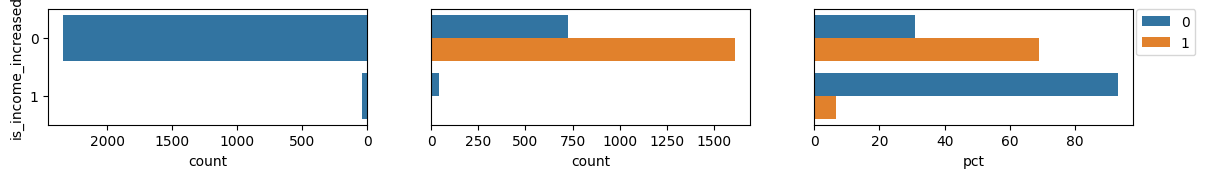

In [ ]:
analyse_categorical_variable(data=df_agg, var='is_income_increased', target_var='is_churned')

Testing for Dependance (Chi2 Test)
Since pval (0.000) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (is_rating_increased): Significnatly Dependant


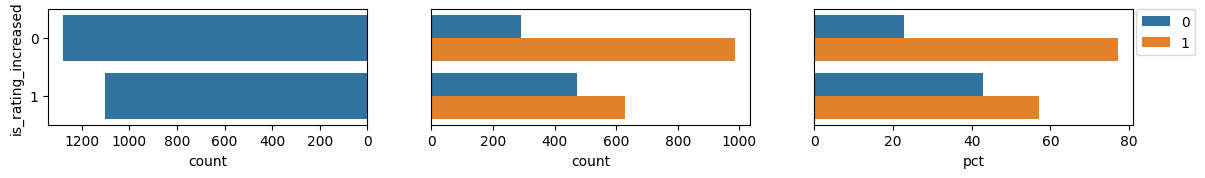

In [ ]:
analyse_categorical_variable(data=df_agg, var='is_rating_increased', target_var='is_churned')

In [ ]:
analyse_categorical_variable(data=df_agg, var='City', target_var='is_churned')

Testing for Dependance (Chi2 Test)
Since pval (0.014) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (City): Significnatly Dependant


Testing for Dependance (Chi2 Test)
Since pval (0.716) > significance level (0.05), Dependant variable (is_churned) and Predictor variable (Gender): Not Dependant


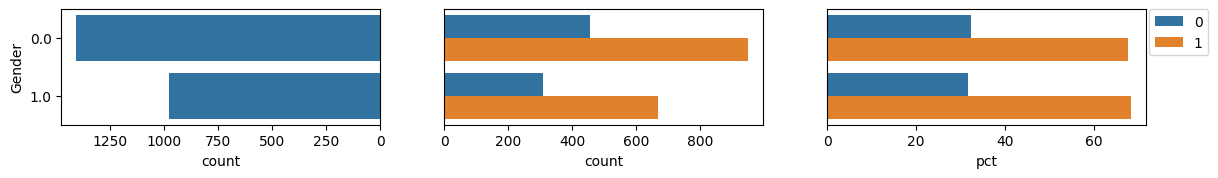

In [ ]:
analyse_categorical_variable(data=df_agg, var='Gender', target_var='is_churned')

In [ ]:
df_agg = df_agg.drop('Gender', axis=1)

Since target variable is not significantly dependant of predictor variable, we drop the variable from further analysis.

Testing for Dependance (Chi2 Test)
Since pval (0.466) > significance level (0.05), Dependant variable (is_churned) and Predictor variable (Education_Level): Not Dependant


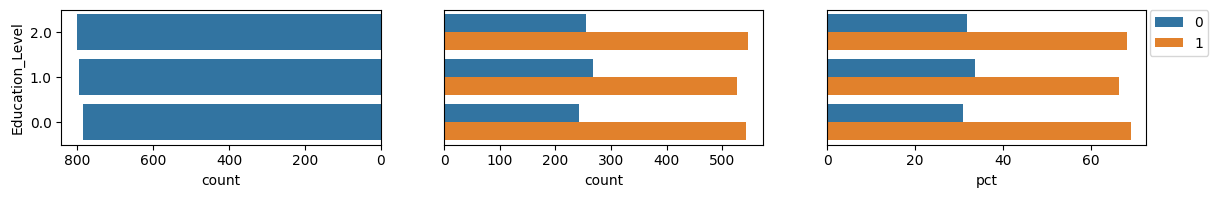

In [ ]:
analyse_categorical_variable(data=df_agg, var='Education_Level', target_var='is_churned')

In [ ]:
df_agg = df_agg.drop('Education_Level', axis=1)

Since target variable is not significantly dependant of predictor variable, we drop the variable from further analysis.

Testing for Dependance (Chi2 Test)
Since pval (0.000) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (Joining Designation): Significnatly Dependant


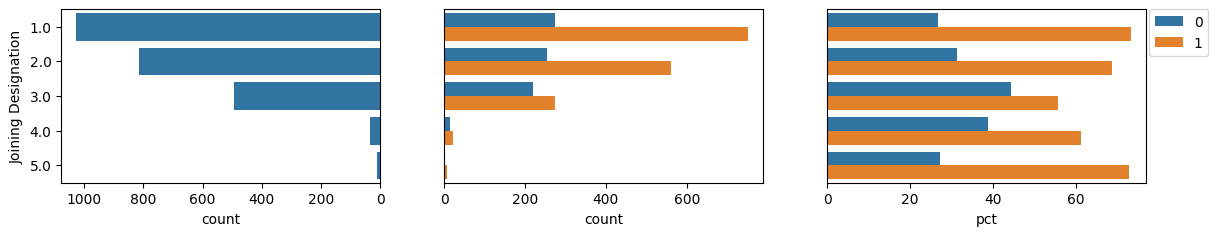

In [ ]:
analyse_categorical_variable(data=df_agg, var='Joining Designation', target_var='is_churned')

Testing for Dependance (Chi2 Test)
Since pval (0.000) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (Grade): Significnatly Dependant


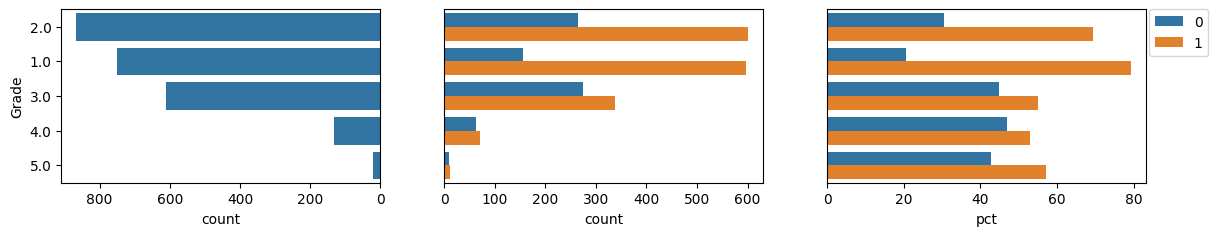

In [ ]:
analyse_categorical_variable(data=df_agg, var='Grade', target_var='is_churned')

Testing for Dependance (Chi2 Test)
Since pval (0.000) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (Quarterly Rating): Significnatly Dependant


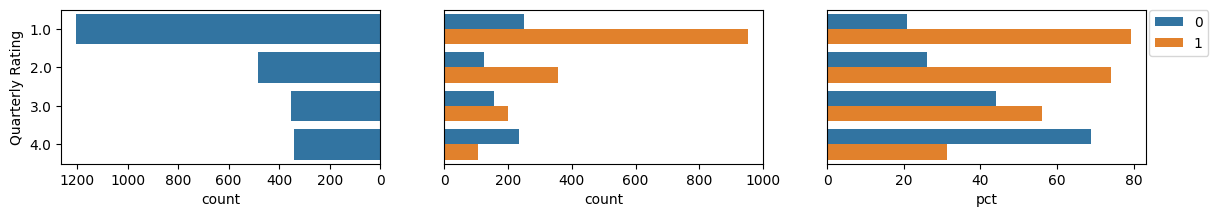

In [ ]:
analyse_categorical_variable(data=df_agg, var='Quarterly Rating', target_var='is_churned')

---

Testing for Correlation (KS Test)
Since pval (0.000) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (tenure_months): Significnatly Dependant


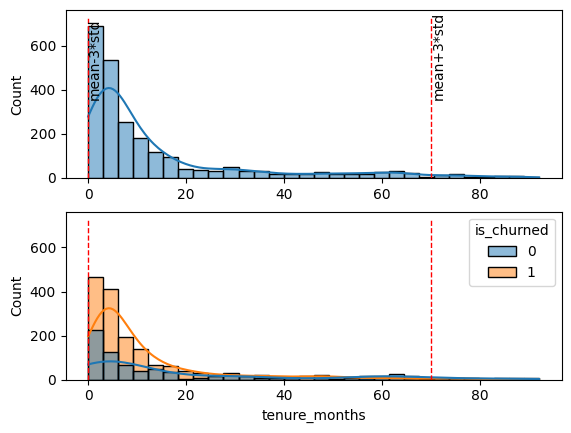

In [ ]:
analyse_numeric_variable(data=df_agg, var='tenure_months', target_var='is_churned')

Testing for Correlation (KS Test)
Since pval (0.003) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (Age): Significnatly Dependant


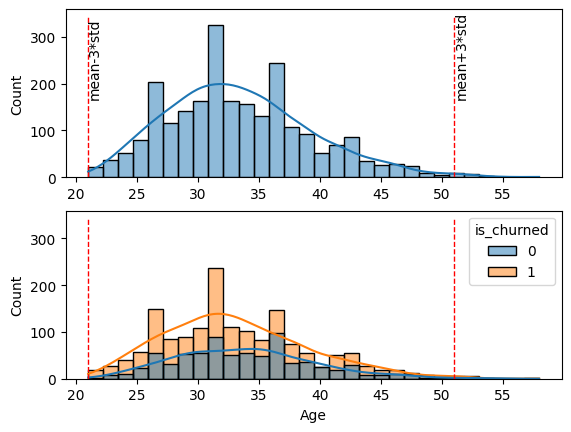

In [ ]:
analyse_numeric_variable(data=df_agg, var='Age', target_var='is_churned')

Testing for Correlation (KS Test)
Since pval (0.000) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (Income): Significnatly Dependant


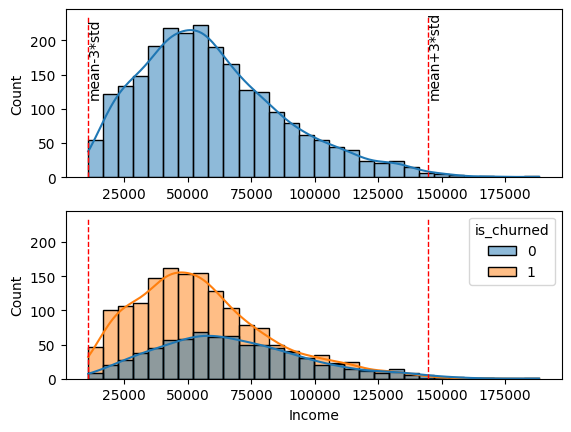

In [ ]:
analyse_numeric_variable(data=df_agg, var='Income', target_var='is_churned')

Testing for Correlation (KS Test)
Since pval (0.000) <= significance level (0.05), Dependant variable (is_churned) and Predictor variable (Total Business Value): Significnatly Dependant


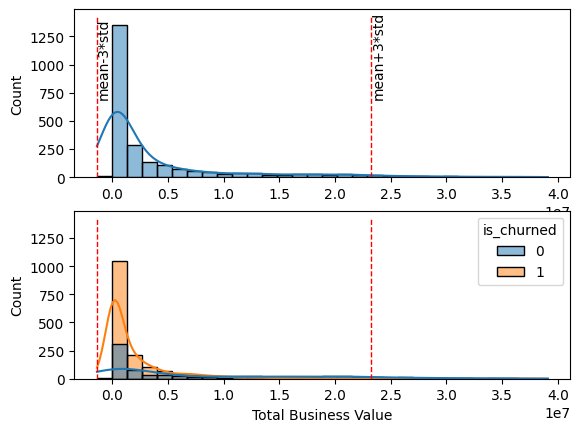

In [ ]:
analyse_numeric_variable(data=df_agg, var='Total Business Value', target_var='is_churned')

---

# Handling class imbalance

In [ ]:
df_agg['is_churned'].value_counts(normalize=True)

1    0.678706
0    0.321294
Name: is_churned, dtype: float64

In [ ]:
df_agg['is_churned'].value_counts()

1    1616
0     765
Name: is_churned, dtype: int64

In [ ]:
smote = SMOTE(sampling_strategy="minority")
X_res, y_res = smote.fit_resample(df_agg.drop("is_churned", axis=1), df_agg["is_churned"])

In [ ]:
y_res.value_counts()

1    1616
0    1616
Name: is_churned, dtype: int64

---

# Train-Test Split, Standardization, Model Building, Performance Evaluation

## Bagging Algorithm

In [ ]:
# split data into train and test sets with cross-validation
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, stratify=y_res, random_state=42)

# standardize features
scaler = StandardScaler()
scaler = scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# create bagging classifier object
bagging = BaggingClassifier()

# define hyperparameter grid to search over
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 1.0],
    'max_features': [0.5, 1.0],
    'bootstrap': [True, False]
}

# perform grid search with cross-validation
grid_search = GridSearchCV(bagging, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

In [ ]:
# print best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'bootstrap': False, 'max_features': 0.5, 'max_samples': 0.5, 'n_estimators': 100}


In [ ]:
# predict on test data
y_pred = grid_search.predict(X_test)

In [ ]:
# evaluate model performance
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[395  90]
 [ 53 432]]


Although the bagging model has a reasonable performance (~85% accuracy), we see that the number of false positive predictions (FP) and false negative predictions (FN) is quite high.

In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.81      0.85       485
           1       0.83      0.89      0.86       485

    accuracy                           0.85       970
   macro avg       0.85      0.85      0.85       970
weighted avg       0.85      0.85      0.85       970



We can see that the model has an accuracy of 0.85, which means that it correctly classified 85% of the samples in the test set. The precision for class 0 is 0.88, which means that when the model predicted a negative class (0), it was correct 88% of the time. The recall for class 0 is 0.81, which means that the model correctly identified 81% of the actual negative samples. The F1 score for class 0 is 0.85, which is the harmonic mean of precision and recall for class 0.

Similarly, for class 1, the precision is 0.83, which means that when the model predicted a positive class (1), it was correct 83% of the time. The recall for class 1 is 0.89, which means that the model correctly identified 89% of the actual positive samples. The F1 score for class 1 is 0.86, which is the harmonic mean of precision and recall for class 1.

In general, we can say that the model has reasonable performance based on the precision, recall, and F1 score for both classes. The weighted average of precision, recall, and F1 score is also 0.85, which indicates that the model is balanced in terms of classification performance across both classes. The macro average of precision, recall, and F1 score is also 0.85, which means that the model's performance for both classes is similar.

ROC AUC Score: 0.8525773195876288


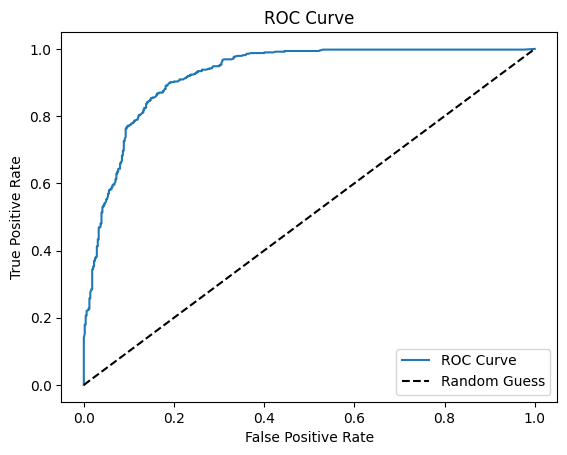

In [ ]:
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

# plot ROC curve
y_prob = grid_search.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

 The ROC AUC score is 0.8525, which is greater than 0.5, indicating that the model is better than random at distinguishing between the positive and negative classes.

---

## Boosting Algorithm

In [ ]:
# create gradient boosting classifier object
gb = GradientBoostingClassifier()

# define hyperparameter grid to search over
param_grid_01 = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'max_depth': [2, 3, 4],
    'subsample': [0.5, 0.8, 1.0]
}

# perform grid search with cross-validation
grid_search_01 = GridSearchCV(gb, param_grid=param_grid_01, cv=5)
grid_search_01.fit(X_train, y_train)

In [ ]:
# print best hyperparameters
print("Best Hyperparameters:", grid_search_01.best_params_)

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}


In [ ]:
# predict on test data
y_pred_01 = grid_search_01.predict(X_test)

In [ ]:
# evaluate model performance
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_01))

Confusion Matrix:
 [[406  79]
 [ 57 428]]


Compared to the previous confusion matrix (Bagging model), we see that the number of false positive predictions (FP) has decreased, while the number of false negative predictions (FN) has increased.

In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred_01))

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       485
           1       0.84      0.88      0.86       485

    accuracy                           0.86       970
   macro avg       0.86      0.86      0.86       970
weighted avg       0.86      0.86      0.86       970



We can see that the model has an accuracy of 0.86, which means that it correctly classified 86% of the samples in the test set. The precision for class 0 is 0.88, which means that when the model predicted a negative class (0), it was correct 88% of the time. The recall for class 0 is 0.84, which means that the model correctly identified 84% of the actual negative samples. The F1 score for class 0 is 0.86, which is the harmonic mean of precision and recall for class 0.

Similarly, for class 1, the precision is 0.84, which means that when the model predicted a positive class (1), it was correct 84% of the time. The recall for class 1 is 0.88, which means that the model correctly identified 88% of the actual positive samples. The F1 score for class 1 is 0.86, which is the harmonic mean of precision and recall for class 1.

In general, we can say that the model has reasonable performance based on the precision, recall, and F1 score for both classes. The weighted average of precision, recall, and F1 score is also 0.86, which indicates that the model is balanced in terms of classification performance across both classes.

The macro average of precision, recall, and F1 score is also 0.86, which means that the model's performance for both classes is similar.

ROC AUC Score: 0.8597938144329897


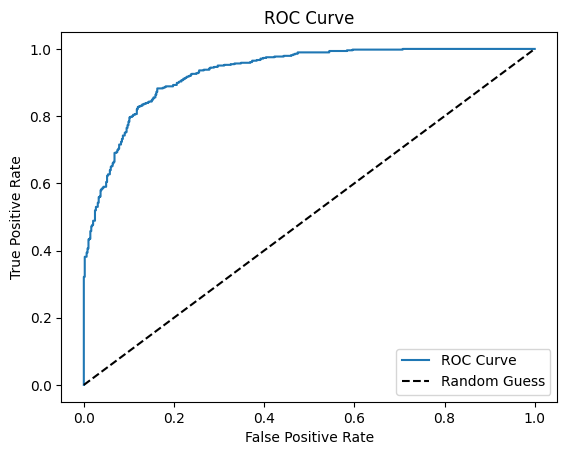

In [ ]:
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_01))

# plot ROC curve
y_prob = grid_search_01.predict_proba(X_test)[:, 1]
fpr, tpr, grid_search_02 = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

The ROC AUC score is 0.8598, which is greater than 0.5, indicating that the model is better than random at distinguishing between the positive and negative classes.

---

## Understanding Feature Importance for Business Insights

In [ ]:
# Train a Boosting model with best parameters
model_02 = GradientBoostingClassifier(learning_rate= 0.1, max_depth= 4, n_estimators= 100, subsample= 1.0)

# Fit the model to the data
model_02.fit(X_train, y_train)

feature_names_02 = X_res.columns.values

feature_importances_02 = np.mean([tree[0].feature_importances_ for tree in model_02.estimators_], axis=0)

output_02 = {fn:round(fi, 3) for fn,fi in zip(feature_names_02,feature_importances_02)}
print(output_02)

{'Age': 0.098, 'City': 0.085, 'Income': 0.198, 'Joining Designation': 0.115, 'Grade': 0.048, 'Total Business Value': 0.229, 'Quarterly Rating': 0.068, 'is_income_increased': 0.0, 'is_rating_increased': 0.01, 'tenure_months': 0.15}


In [ ]:
pd.Series(output_02).sort_values(ascending=False)

Total Business Value    0.229
Income                  0.198
tenure_months           0.150
Joining Designation     0.115
Age                     0.098
City                    0.085
Quarterly Rating        0.068
Grade                   0.048
is_rating_increased     0.010
is_income_increased     0.000
dtype: float64

In [ ]:
# Train a Bagging model with best parameters
model_01 = BaggingClassifier(bootstrap=False, max_features= 0.5, max_samples= 0.5, n_estimators= 100)

# Fit the model to the data
model_01.fit(X_train, y_train)

feature_names = X_res.columns.values

feature_importances = np.mean([tree.feature_importances_ for tree in model_01.estimators_], axis=0)

output = {fn:fi for fn,fi in zip(feature_names,feature_importances)}
print(output)

{'Age': 0.2134691523269167, 'City': 0.20689059926438444, 'Income': 0.20140645677455823, 'Joining Designation': 0.19977467377990202, 'Grade': 0.17845911785423862}


In [ ]:
pd.Series(output).sort_values(ascending=False)

Age                    0.213469
City                   0.206891
Income                 0.201406
Joining Designation    0.199775
Grade                  0.178459
dtype: float64

---

## Business Insights and Recommendataion

For the GradientBoostingClassifier model, we can see that the most important feature is "Total Business Value" with an importance value of 0.229, followed by "Income" with an importance of 0.198 and "tenure_months" with an importance of 0.150. The least important feature is "is_income_increased" with an importance of 0.000.

For the BaggingClassifier model, we can see that the most important feature is "Age" with an importance value of 0.213, followed by "City" with an importance of 0.207 and "Income" with an importance of 0.201. The least important feature is "Grade" with an importance of 0.178.

The fact that the same features are important in both models suggests that these features are the most predictive of a driver's performance. This means that if you want to avoid driver's churn, you should focus on improving these features.

For example, if you want to increase a driver's total business value, you could try to increase their income or tenure. If you want to improve a driver's quarterly rating, you could try to increase their grade.

Of course, the feature importances are just a guide. They don't guarantee that improving these features will definitely reduce a driver's churn rate. However, they do suggest that these features are the most important ones to focus on.